## **Task 3 - Use the given YOLO model to identify cones.**

<img src="YOLO.png">

In [18]:
from ultralytics import YOLO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [19]:
model = YOLO("YOLOv11s-Carmaker.pt")

# model.train(data="", epochs=100, imgsz=640)     

results = model.predict('cones.png' , show=True)

YOLO_data = results[0].boxes.data.cpu().numpy()
print(model.names) # provides the class id of the particular color cone. 
print(YOLO_data)

# colors = {
#     1: (255, 165, 0),   
#     3: (135, 206, 235),   
#     2: (0, 0, 255)    
# }

results[0].boxes.xyxy
results[0].boxes.cls   #ye note karoo. [0] kyu aya aur xyxy aur xywh alag hai..


image 1/1 /home/maulik/Documents/IITB-Racing/Perception/Task 3/cones.png: 384x640 3 Blues, 2 Small Oranges, 3 Yellows, 104.0ms
Speed: 9.6ms preprocess, 104.0ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
{0: 'Big Orange', 1: 'Blue', 2: 'Small Orange', 3: 'Yellow'}
[[     312.52      485.03      367.24      569.84       0.933           3]
 [     473.64      479.41       522.6      553.67      0.9264           3]
 [     659.58      497.35       723.8      598.33     0.92376           3]
 [     532.41      480.98      582.25      554.42     0.85595           2]
 [     405.51      477.47      457.45      545.18     0.80567           1]
 [     580.82      486.65      637.71      570.98     0.74933           2]
 [     233.68      496.88      301.89      582.61     0.73374           1]
 [      739.9      511.37      842.46      623.44     0.56463           1]]


tensor([3., 3., 3., 2., 1., 2., 1., 1.])

In [20]:
datalist = []

for i in range(8):
    x_1 = YOLO_data[i][0]
    y_1 = YOLO_data[i][1]
    x_2 = YOLO_data[i][2]
    y_2 = YOLO_data[i][3]

    if(YOLO_data[i][5]==1):
        color = "blue"

    if(YOLO_data[i][5]==2):
        color = "orange"

    if(YOLO_data[i][5]==3):
        color = "yellow"

    datalist.append({
        'color': color,
        'x_1': int(x_1),
        'y_1': int(y_1),
        'x_2': int(x_2),
        'y_2': int(y_2),

    })

corners = pd.DataFrame(datalist)
corners.head(8)

,color,x_1,y_1,x_2,y_2
0,yellow,312,485,367,569
1,yellow,473,479,522,553
2,yellow,659,497,723,598
3,orange,532,480,582,554
4,blue,405,477,457,545
5,orange,580,486,637,570
6,blue,233,496,301,582
7,blue,739,511,842,623


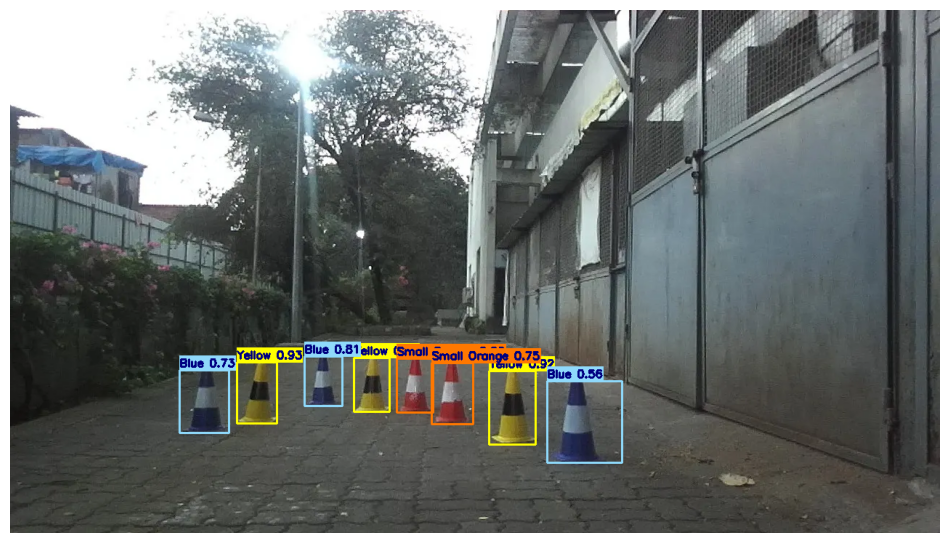

In [21]:
cones = cv2.imread("cones.png")

cones = cv2.cvtColor(cones, cv2.COLOR_BGR2RGB)   #there is some issue with cv2, BGR shit something. #also yolo ka output iss case mein kuch aur thaa....

thickness = 2

for i in range(8):
    start = (corners['x_1'][i],corners['y_1'][i])
    end = (corners['x_2'][i], corners['y_2'][i])

    if(corners['color'][i] == 'yellow'):
        color = (255,255,0)

    if(corners['color'][i] == 'orange'):
        color = (255,120,0)

    if(corners['color'][i] == 'blue'):
        color = (0,0,255)

    cv2.rectangle(cones, start, end, color, thickness)

colors = {1: (143, 217, 251), 3: (255, 255,0), 2: (255, 120, 0)}




for box in results[0].boxes:
    # 1. Get Coordinates
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    
    # 2. Get Class and Confidence
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    label = f"{model.names[cls_id]} {conf:.2f}"
    
    # 3. Choose Color (Default to Green if ID not in dict)
    color = colors.get(cls_id, (0, 255, 0))
    
    # --- DRAWING ---
    # A. Draw the Box
    cv2.rectangle(cones, (x1, y1), (x2, y2), color, 2)
    
    # B. Draw the Label Background (So text is readable)
    (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    cv2.rectangle(cones, (x1, y1 - 20), (x1 + w, y1), color, -1) # -1 fills it
    
    # C. Draw the Text
    cv2.putText(cones, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,128), 2)


    

plt.figure(figsize=(12,7))
 
plt.imshow(cones)
plt.axis('off')
plt.show()

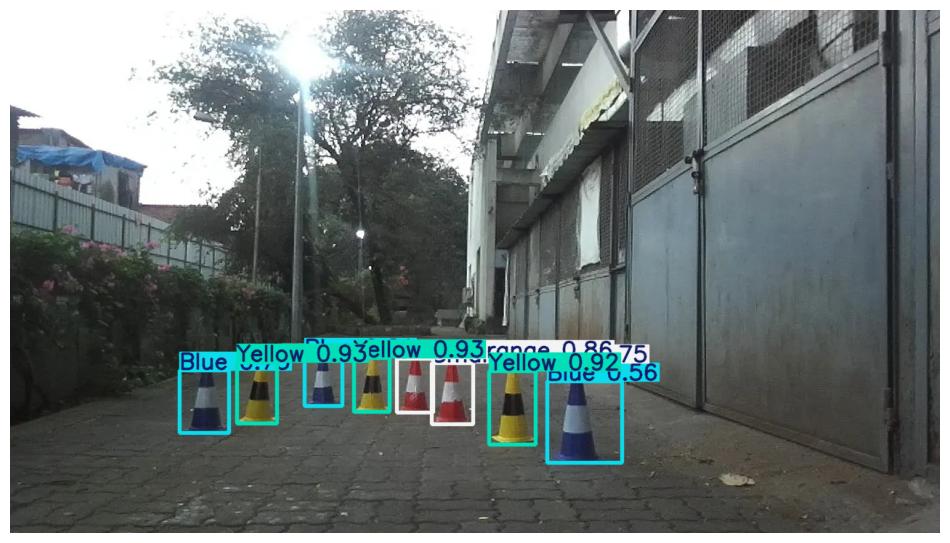

In [24]:
res_plot = results[0].plot()

res_plot = cv2.cvtColor(res_plot, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,7))
plt.imshow(res_plot)
plt.axis('off')
plt.show()